# 02 Sequential credit and scaling

Every displayed result is computed from the scientific implementation in this repository. The reduced default uses fewer seeds/episodes and parallel independent cells; `publication` restores the original budgets. Numerical archives are an explicit opt-in and are never required for the live default. Figures display inline once and saving is disabled unless requested.

## Configuration

In [2]:
from pathlib import Path
import hashlib, json, os, sys

# One BLAS thread per process: independent scientific cells are parallelised instead.
for _name in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_name, "1")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

RUN_PROFILE = os.getenv("MRL_RUN_PROFILE", "reduced")  # smoke | reduced | publication
DEVICE = os.getenv("MRL_DEVICE", "auto")
WORKERS = os.getenv("MRL_WORKERS", "auto")
SAVE_FIGURES = os.getenv("MRL_SAVE_FIGURES", "0") == "1"
OUTPUT_DIR = Path(os.getenv("MRL_OUTPUT_DIR", "generated_figures"))
OVERWRITE = os.getenv("MRL_OVERWRITE", "0") == "1"
RUN_EXTERNAL_DATA = os.getenv("MRL_RUN_EXTERNAL_DATA", "0") == "1"
ALLOW_DATA_DOWNLOADS = os.getenv("MRL_ALLOW_DATA_DOWNLOADS", "0") == "1"
USE_ARCHIVED_RESULTS = os.getenv("MRL_USE_ARCHIVED_RESULTS", os.getenv("MRL_USE_NUMERICAL_ARCHIVES", "0")) == "1"

if RUN_PROFILE not in {"smoke", "reduced", "publication"}:
    raise ValueError(f"unknown RUN_PROFILE={RUN_PROFILE!r}")

HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == "experiments" else HERE
sys.path.insert(0, str(ROOT / "src"))
RESULTS = ROOT / "data" / "results"
MANIFEST = json.loads((ROOT / "data" / "publication" / "figure_manifest.json").read_text())
FIGURES = {row["filename"]: row for row in MANIFEST["figures"]}
OWNED = ("fig_dmax_dense.png", "fig_sequential.png", "fig_scaling.png", "fig_hybrid.png")
FIGURE_REPORT = []

cpu = os.cpu_count() or 4
RESOLVED_WORKERS = max(1, min(8, cpu - 2)) if WORKERS == "auto" else max(1, int(WORKERS))

try:
    import torch
    if DEVICE == "cpu":
        SELECTED_DEVICE = "cpu"
    elif torch.cuda.is_available():
        SELECTED_DEVICE = "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        SELECTED_DEVICE = "mps"
    else:
        SELECTED_DEVICE = "cpu"
except ImportError:
    SELECTED_DEVICE = "cpu"

print({"profile": RUN_PROFILE, "requested_device": DEVICE, "selected_device": SELECTED_DEVICE,
       "workers": RESOLVED_WORKERS, "saving": SAVE_FIGURES,
       "numerical_archives": USE_ARCHIVED_RESULTS, "python": sys.executable})

{'profile': 'reduced', 'requested_device': 'auto', 'selected_device': 'cuda', 'workers': 8, 'saving': False, 'numerical_archives': False, 'python': 'c:\\Users\\User\\anaconda3\\envs\\mnn_torch\\python.exe'}


## Inline display, optional saving, and provenance

In [3]:
def _normalise(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(k): _normalise(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_normalise(v) for v in value]
    return value

def data_hash(value):
    blob = json.dumps(_normalise(value), sort_keys=True, separators=(",", ":"), default=str)
    return hashlib.sha256(blob.encode()).hexdigest()

def load_archive(name):
    path = RESULTS / name
    if not (USE_ARCHIVED_RESULTS and path.exists()):
        return None
    value = np.load(path, allow_pickle=True).item()
    print(f"using optional numerical archive: {path.name}")
    return value

def _safe_save(fig, filename):
    if not SAVE_FIGURES:
        return None
    out = OUTPUT_DIR.expanduser().resolve()
    if "manuscript" in str(out).lower() and not OVERWRITE:
        raise FileExistsError("writing into a manuscript directory requires OVERWRITE=True")
    out.mkdir(parents=True, exist_ok=True)
    path = out / filename
    if path.exists() and not OVERWRITE:
        raise FileExistsError(path)
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    return str(path)

def finish(fig, filename, source, meta):
    saved = _safe_save(fig, filename)
    record = dict(FIGURES.get(filename, {"filename": filename}),
                  provenance_class=("published-aggregate" if source.startswith("numerical-archive") else source),
                  claim_status=("aggregate-reproduction" if source.startswith("numerical-archive") else
                                "exact-reproduction" if source == "live-exact" else "reduced-validation"),
                  runtime_profile=RUN_PROFILE, runtime_device=LIVE_DEVICE,
                  runtime_workers=RESOLVED_WORKERS, runtime_source=source,
                  runtime_meta=_normalise(meta), data_hash=data_hash(meta), saved_path=saved,
                  display_status="generated live" if source.startswith("live") else source)
    FIGURE_REPORT.append(record)
    display(fig)
    plt.close(fig)
    return record

## Retention–delay scaling law

The reduced profile evaluates the same T-maze device model at fixed delay/retention ratios, concentrating live samples around the criterion crossing. Publication mode restores the authored dense absolute-delay grid; an available numerical archive can instead be selected explicitly.

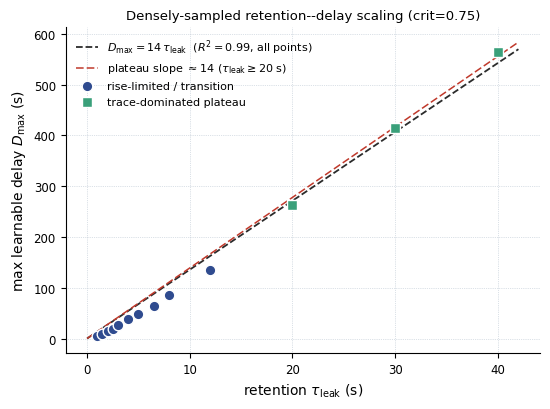

In [4]:
from mrl_trace.maze import run_dmax_adaptive, run_dmax_law

dmax_result = load_archive("exp8_dmax_law.npy")
if dmax_result is None:
    if RUN_PROFILE == "smoke":
        dmax_result = run_dmax_adaptive(seeds=1, episodes=40, taus=(1, 5, 20, 40),
                                        delay_ratios=(8, 16), workers=min(2, RESOLVED_WORKERS))
    elif RUN_PROFILE == "reduced":
        dmax_result = run_dmax_adaptive(seeds=3, episodes=220, workers=RESOLVED_WORKERS)
    else:
        dmax_result = run_dmax_law(seeds=20, episodes=800, workers=RESOLVED_WORKERS)
    LIVE_SOURCE = "live-exact" if RUN_PROFILE == "publication" else "live-reduced"
else:
    LIVE_SOURCE = f"numerical-archive ({dmax_result.get('seeds', 'unknown')} seeds)"

taus = np.asarray(dmax_result["taus"], float)
dvals = np.asarray([dmax_result["dmax"][t] for t in dmax_result["taus"]], float)
censored = np.asarray(dmax_result["censored"], bool)
fitmask = (~censored) & (dvals > 0)
k, r2 = dmax_result["k"], dmax_result["r2"]
k_plateau = dmax_result["k_plateau"]
plateau_tau = dmax_result["plateau_tau"]
crit = dmax_result["crit"]
LIVE_DEVICE = "cpu"
LIVE_META = dmax_result

INK = "#2b2b2b"; BRICK = "#c0392b"; INDIGO = "#2f4b8f"; TEAL = "#3aa07a"; GRID = "#b8c4d0"
def _figure(taus, dvals, censored, fitmask, k, r2, k_plateau, plateau_tau, crit):
    fig, ax = plt.subplots(figsize=(5.6, 4.2))
    xx = np.linspace(0, taus.max() * 1.05, 100)
    # headline origin fit over all resolved points
    ax.plot(xx, k * xx, color=INK, lw=1.3, ls="--", zorder=2,
            label=fr"$D_{{\max}} = {k:.0f}\,\tau_{{\rm leak}}$  ($R^2={r2:.2f}$, all points)")
    # asymptotic plateau slope (steeper; the trace-dominated regime)
    ax.plot(xx, k_plateau * xx, color=BRICK, lw=1.1, ls=(0, (5, 2)), zorder=2,
            label=fr"plateau slope $\approx{k_plateau:.0f}$ ($\tau_{{\rm leak}}\geq{plateau_tau:g}$ s)")
    rise = fitmask & (taus < plateau_tau)
    plat = fitmask & (taus >= plateau_tau)
    ax.scatter(taus[rise], dvals[rise], s=58, color=INDIGO, edgecolor="white",
               zorder=4, label="rise-limited / transition")
    ax.scatter(taus[plat], dvals[plat], s=58, marker="s", color=TEAL, edgecolor="white",
               zorder=4, label="trace-dominated plateau")
    if censored.any():
        ax.scatter(taus[censored], dvals[censored], s=58, marker="^", color="#e0a93b",
                   edgecolor="white", zorder=4,
                   label="censored ($D_{\\max}\\geq$ grid max)")
    ax.set_xlabel(r"retention $\tau_{\rm leak}$ (s)", fontsize=10)
    ax.set_ylabel(r"max learnable delay $D_{\max}$ (s)", fontsize=10)
    ax.grid(True, ls=":", lw=0.5, color=GRID); ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8.5)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(f"Densely-sampled retention--delay scaling (crit={crit})",
                 fontsize=9.5)
    fig.tight_layout()
    finish(fig, "fig_dmax_dense.png", LIVE_SOURCE, LIVE_META)



_figure(taus, dvals, censored, fitmask, k, r2, k_plateau, plateau_tau, crit)

## Sequential T-maze benchmark

All four learning conditions and every retention × delay cell are run independently. The plotting function below is retained from the authored source generator, including its labels, axes, colours, and confidence bands.

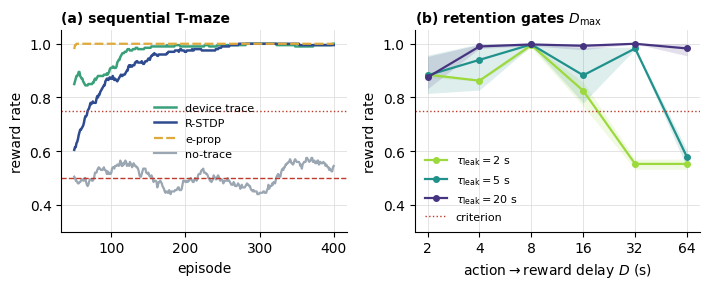

In [5]:
from mrl_trace.maze import run_sequential

seq_result = load_archive("exp6_sequential.npy")
if seq_result is None:
    if RUN_PROFILE == "smoke":
        seq_result = run_sequential(seeds=1, episodes=80, taus=(2., 5., 20.),
                                    delays=(2, 8, 32), workers=min(2, RESOLVED_WORKERS))
    elif RUN_PROFILE == "reduced":
        seq_result = run_sequential(seeds=4, episodes=400, workers=RESOLVED_WORKERS)
    else:
        seq_result = run_sequential(seeds=20, episodes=800, workers=RESOLVED_WORKERS)
    LIVE_SOURCE = "live-exact" if RUN_PROFILE == "publication" else "live-reduced"
else:
    LIVE_SOURCE = f"numerical-archive ({seq_result.get('seeds', 'unknown')} seeds)"

curves, grid, grid_ci = seq_result["curves"], np.asarray(seq_result["grid"]), np.asarray(seq_result["grid_ci"])
taus, delays = seq_result["taus"], seq_result["delays"]
chance, crit = seq_result["chance"], seq_result["crit"]
LIVE_DEVICE = "cpu"
LIVE_META = seq_result
DEVC = "#3aa07a"; RSTDP = "#2f4b8f"; NTC = "#9aa6b2"; CR = "#c0392b"
def _figure(curves, grid, grid_ci, taus, delays, chance, crit):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.2, 3.0))
    tt = np.arange(50, 50 + len(curves["device"]))
    axA.plot(tt, curves["device"], color=DEVC, lw=1.8, label="device trace")
    axA.plot(tt, curves["rstdp"], color=RSTDP, lw=1.8, label="R-STDP")
    if "eprop" in curves:
        axA.plot(tt, curves["eprop"], color="#e0a93b", lw=1.6, ls=(0, (4, 1.5)),
                 label="e-prop")
    axA.plot(tt, curves["no_trace"], color=NTC, lw=1.6, label="no-trace")
    axA.axhline(chance, ls="--", color=CR, lw=1.0)
    axA.axhline(crit, ls=":", color=CR, lw=1.0)
    axA.set_xlabel("episode"); axA.set_ylabel("reward rate")
    axA.set_ylim(0.3, 1.05); axA.set_title("(a) sequential T-maze", loc="left",
                                           fontsize=10, fontweight="bold")
    axA.grid(True, which="major", color="0.85", lw=0.5, zorder=0); axA.set_axisbelow(True)
    axA.legend(frameon=False, fontsize=8); axA.spines[["top", "right"]].set_visible(False)

    cols = [plt.cm.viridis(x) for x in (0.85, 0.5, 0.15)]   # sequential by retention
    for i, tau in enumerate(taus):
        axB.plot(delays, grid[i], marker="o", ms=4, lw=1.6, color=cols[i % 3],
                 label=fr"$\tau_{{\rm leak}}={tau:g}$ s")
        axB.fill_between(delays, grid_ci[i, :, 0], grid_ci[i, :, 1],
                         color=cols[i % 3], alpha=0.15, lw=0)
    axB.axhline(crit, ls=":", color=CR, lw=1.0, label="criterion")
    axB.set_xscale("log"); axB.set_xlabel(r"action$\to$reward delay $D$ (s)")
    # Clean integer ticks at the measured delays; suppress the default log
    # minor-tick labels (2x10^0, 3x10^0, ...) that otherwise clutter the axis.
    axB.set_xticks(list(delays))
    axB.set_xticklabels([f"{d:g}" for d in delays])
    axB.xaxis.set_minor_formatter(mticker.NullFormatter())
    axB.tick_params(axis="x", which="minor", length=0)
    axB.set_ylabel("reward rate"); axB.set_ylim(0.3, 1.05)
    axB.set_title("(b) retention gates $D_{\\max}$", loc="left",
                  fontsize=10, fontweight="bold")
    # gridlines at the (log-x) major delay ticks and on y, behind the data
    axB.grid(True, which="major", color="0.85", lw=0.5, zorder=0)
    axB.set_axisbelow(True)
    axB.legend(frameon=False, fontsize=8); axB.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    finish(fig, "fig_sequential.png", LIVE_SOURCE, LIVE_META)



_figure(curves, grid, grid_ci, taus, delays, chance, crit)

## Closed-loop scaling and remedies

The reduced run retains all six array sizes and all five interventions, using a shorter trial budget. The two panels use the authored source generator verbatim; only their live result objects replace the original `.npy` loads.

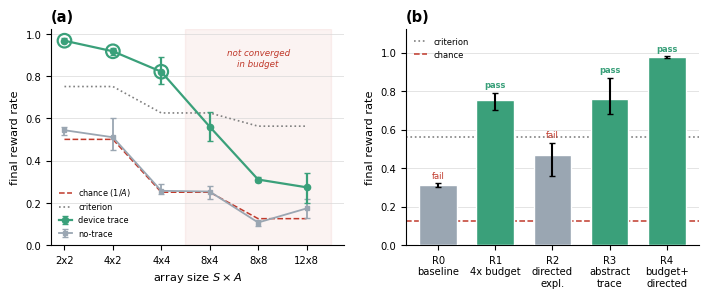

{'filename': 'fig_scaling.png',
 'tier': 'supplementary',
 'notebook': '02_sequential_and_scaling.ipynb',
 'profile': 'reduced',
 'device': 'cpu',
 'seeds': 3,
 'data_hash': '911a596a69643ba782ed49ff97e7508195caff154a374bf355debe9c210fa889',
 'reference_hash': 'f303f860137bc437b2cb819d5014fe31de21e135bb36eac4735c4af9dc08ce91',
 'provenance_class': 'live-reduced',
 'claim_status': 'reduced-validation',
 'runtime_profile': 'reduced',
 'runtime_device': 'cpu',
 'runtime_workers': 8,
 'runtime_source': 'live-reduced',
 'runtime_meta': {'scaling': {'(2, 2)': {'chance': 0.5,
    'crit': 0.75,
    'device': [0.9666666666666667, 0.009428090415820642, 0.96, 0.98],
    'no_trace': [0.5433333333333333, 0.016996731711975962, 0.52, 0.56],
    'trials_to_crit': 273,
    'n_converged': 3,
    'passed': True,
    'n_seeds': 3,
    'trials': 1500},
   '(4, 2)': {'chance': 0.5,
    'crit': 0.75,
    'device': [0.9166666666666666, 0.012472191289246483, 0.9, 0.93],
    'no_trace': [0.5099999999999999, 0.0

In [6]:
from mrl_trace.bandit import run_remedies, run_scaling

r4 = load_archive("tier4_results.npy")
r5 = load_archive("tier5_results.npy")
if r4 is None or r5 is None:
    if RUN_PROFILE == "smoke":
        seeds, trials, mult, workers = 1, 30, 2, min(2, RESOLVED_WORKERS)
    elif RUN_PROFILE == "reduced":
        # Keep a small seed batch, but preserve the authored 1500-trial convergence
        # budget: shortening this axis changes the scaling/remedy claim, not just its CI.
        seeds, trials, mult, workers = 3, 1500, 4, RESOLVED_WORKERS
    else:
        seeds, trials, mult, workers = 20, 1500, 4, RESOLVED_WORKERS
    r4 = run_scaling(seeds=seeds, trials=trials, workers=workers)
    r5 = run_remedies(seeds=seeds, trials=trials, budget_multiplier=mult, workers=workers)
    LIVE_SOURCE = "live-exact" if RUN_PROFILE == "publication" else "live-reduced"
else:
    LIVE_SOURCE = "numerical-archive"
LIVE_DEVICE = "cpu"
LIVE_META = {"scaling": r4, "remedies": r5}
DEVC = "#3aa07a"; NTC = "#9aa6b2"; CR = "#c0392b"; CH = "#2b2b2b"; OKC = "#3aa07a"

fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.0, 2.9))

# ---------------- Panel (a): scaling ----------------
cells = [(2, 2), (4, 2), (4, 4), (8, 4), (8, 8), (12, 8)]
labels = [f"{S}x{A}" for S, A in cells]
# result tuples are (mean, sd, lo, hi); error bars are the bootstrap 95% CI
def _ci_err(entries):
    m = np.array([e[0] for e in entries])
    lo = np.array([e[2] for e in entries])
    hi = np.array([e[3] for e in entries])
    return m, np.vstack([m - lo, hi - m])

dev, dev_err = _ci_err([r4[c]["device"] for c in cells])
nt, nt_err = _ci_err([r4[c]["no_trace"] for c in cells])
chance = np.array([r4[c]["chance"] for c in cells])
crit = np.array([r4[c]["crit"] for c in cells])
passed = np.array([r4[c]["passed"] for c in cells])
x = np.arange(len(cells))

axA.plot(x, chance, "--", color=CR, lw=1.1, label="chance ($1/A$)", zorder=2)
axA.plot(x, crit, ":", color="0.5", lw=1.2, label="criterion", zorder=2)
axA.errorbar(x, dev, yerr=dev_err, marker="o", ms=4.5, lw=1.6, color=DEVC,
             capsize=2.2, label="device trace", zorder=5)
axA.errorbar(x, nt, yerr=nt_err, marker="s", ms=3.5, lw=1.3, color=NTC,
             capsize=2.2, label="no-trace", zorder=4)
for xi, d, ok in zip(x, dev, passed):
    if ok:
        axA.scatter([xi], [d], s=95, facecolors="none", edgecolors=OKC, lw=1.6, zorder=6)
firstfail = int(np.argmax(~passed)) if np.any(~passed) else len(cells)
if firstfail < len(cells):
    axA.axvspan(firstfail - 0.5, len(cells) - 0.5, color=CR, alpha=0.06, zorder=0)
    # annotate near the top of the shaded band, where all traces have fallen away,
    # so the label sits in clear space rather than under the plotted lines
    axA.text((firstfail + len(cells) - 1) / 2, 0.93, "not converged\nin budget",
             fontsize=6.3, ha="center", va="top", color=CR, style="italic")
axA.set_xticks(x); axA.set_xticklabels(labels, fontsize=6.8, rotation=0)
axA.set_xlabel(r"array size $S\times A$", fontsize=8.2)
axA.set_ylabel("final reward rate", fontsize=8.2)
axA.set_ylim(0, 1.02); axA.tick_params(labelsize=7.2)
axA.legend(fontsize=5.9, frameon=False, loc="lower left", handlelength=1.6)
axA.spines[["top", "right"]].set_visible(False)
axA.grid(True, axis="y", color="0.85", lw=0.5, zorder=0)
axA.set_axisbelow(True)
axA.set_title("(a)", fontsize=10.5, fontweight="bold", loc="left")

# ---------------- Panel (b): remedies on 8x8 ----------------
keys = list(r5.keys())                          # preserves R0..R4 insertion order
short = ["R0\nbaseline", "R1\n4x budget", "R2\ndirected\nexpl.",
         "R3\nabstract\ntrace", "R4\nbudget+\ndirected"]
vals = np.array([r5[k]["final"][0] for k in keys])
# bootstrap 95% CI as asymmetric error bars
lo = np.array([r5[k]["final"][2] for k in keys])
hi = np.array([r5[k]["final"][3] for k in keys])
err = np.vstack([vals - lo, hi - vals])
psd = np.array([r5[k]["passed"] for k in keys])
# colour: passing rows teal/green, failing rows grey
bar_c = [DEVC if ok else NTC for ok in psd]
xb = np.arange(len(keys))
crit88 = 0.5 * (1 + 1.0 / 8)
axB.bar(xb, vals, yerr=err, color=bar_c, capsize=2.5, width=0.66,
        edgecolor="white", zorder=3)
axB.axhline(crit88, ls=":", color="0.5", lw=1.2, zorder=2, label="criterion")
axB.axhline(1.0 / 8, ls="--", color=CR, lw=1.1, zorder=2, label="chance")
for xi, v, h, ok in zip(xb, vals, hi, psd):
    # sit the verdict clear above the upper CI cap
    axB.text(xi, h + 0.03, "pass" if ok else "fail", fontsize=6.0, ha="center",
             color=(OKC if ok else CR), fontweight=("bold" if ok else "normal"))
axB.set_xticks(xb); axB.set_xticklabels(short, fontsize=6.0)
axB.set_ylabel("final reward rate", fontsize=8.2)
axB.set_ylim(0, 1.12); axB.tick_params(labelsize=7.2)
axB.legend(fontsize=6.0, frameon=False, loc="upper left", handlelength=1.6)
axB.spines[["top", "right"]].set_visible(False)
axB.grid(True, axis="y", color="0.85", lw=0.5, zorder=0)
axB.set_axisbelow(True)
axB.set_title("(b)", fontsize=10.5, fontweight="bold", loc="left")

fig.tight_layout(pad=0.4, w_pad=1.5)
finish(fig, "fig_scaling.png", LIVE_SOURCE, LIVE_META)

## Hybrid perception–decision stack

The schematic remains authored code, while panel (b) is generated from a freshly trained convolutional SNN and live three-factor decision runs. CUDA is selected automatically when the active environment provides it; the three decision conditions run in parallel CPU processes.

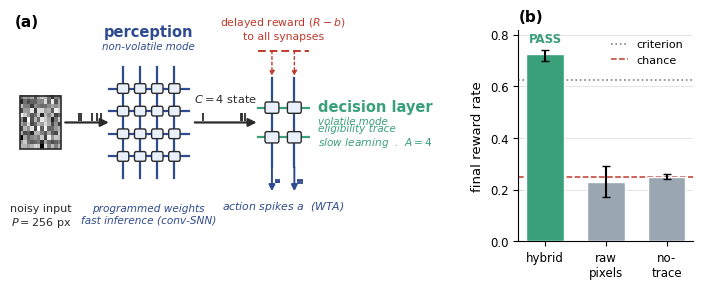

{'filename': 'fig_hybrid.png',
 'tier': 'supplementary',
 'notebook': '02_sequential_and_scaling.ipynb',
 'profile': 'reduced',
 'device': 'cuda',
 'seeds': 3,
 'data_hash': '573fbbf9d7d5da04e017de8c25c4ca9fee56617a109842d6b62e2b332d3d733b',
 'reference_hash': '8e300dc2c4c558cb4e15eb8fd769550cfb50b24070c1bd7d234d9f2f64ca4cc0',
 'provenance_class': 'live-reduced',
 'claim_status': 'reduced-validation',
 'runtime_profile': 'reduced',
 'runtime_device': 'cuda',
 'runtime_workers': 8,
 'runtime_source': 'live-reduced',
 'runtime_meta': {'front_acc': 0.938,
  'chance': 0.25,
  'crit': 0.625,
  'results': {'hybrid': [0.7266666666666666,
    0.018856180831641284,
    0.6999999999999998,
    0.7399999999999999],
   'raw': [0.22999999999999998, 0.04898979485566355, 0.17, 0.29],
   'no_trace': [0.25, 0.008164965809277268, 0.24, 0.26]},
  'C1': True,
  'C2': True,
  'C3': True,
  'C': 4,
  'A': 4,
  'P': 256,
  'noise': 0.9,
  'n_seeds': 3},
 'saved_path': None,
 'display_status': 'generated live

In [7]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
from mrl_trace.hybrid import run_hybrid_decision

# There is intentionally no raster or aggregate fallback for this figure.
if RUN_PROFILE == "smoke":
    hybrid_result = run_hybrid_decision(seeds=1, front_steps=2, per_class=5, trials=10,
                                        workers=min(2, RESOLVED_WORKERS))
elif RUN_PROFILE == "reduced":
    # A small seed/readout sample is lightweight; the 1500-trial decision budget is
    # retained because panel (b)'s convergence criterion depends on it.
    hybrid_result = run_hybrid_decision(seeds=3, front_steps=800, per_class=200, trials=1500,
                                        workers=min(3, RESOLVED_WORKERS))
else:
    hybrid_result = run_hybrid_decision(seeds=20, front_steps=600, per_class=500, trials=1500,
                                        workers=min(3, RESOLVED_WORKERS))
LIVE_SOURCE = "live-exact" if RUN_PROFILE == "publication" else "live-reduced"
LIVE_DEVICE = SELECTED_DEVICE
LIVE_META = hybrid_result
d = hybrid_result
INK = "#2b2b2b"; PERC = "#2f4b8f"; DECC = "#3aa07a"; REW = "#c0392b"
NTC = "#9aa6b2"; OKC = "#3aa07a"; DEV = "#eaf0fb"
STATE = "#3aa07a"; ACT = "#2f4b8f"            # crossbar wordline / bitline colours (cf. Fig 7)

fig = plt.figure(figsize=(7.0, 2.9))
A = fig.add_axes([0.01, 0.05, 0.64, 0.92]); A.axis("off")
B = fig.add_axes([0.73, 0.17, 0.25, 0.73])
A.set_xlim(0, 11); A.set_ylim(1.1, 6.05)


def arrow(ax, p0, p1, color=INK, lw=1.8, ms=12, z=5, ls="-"):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=ms,
                 color=color, lw=lw, ls=ls, zorder=z, shrinkA=0, shrinkB=0))


def memristor(ax, x, y, w=0.34, h=0.2, z=6):
    """Small memristor glyph (filled rounded device) at a crossbar crosspoint."""
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                 boxstyle="round,pad=0.01,rounding_size=0.04",
                 facecolor=DEV, edgecolor=INK, lw=1.0, zorder=z))


def crossbar(ax, cx, cy, ncol, nrow, pitch=0.45, wl_ext=0.35, bl_ext=0.4,
             wl_color=STATE, bl_color=ACT, gw=0.30, gh=0.18, lw=1.6, z=2):
    """Draw a memristive crossbar centred at (cx, cy): nrow horizontal wordlines
    crossed by ncol vertical bitlines, with a device glyph at every crosspoint.
    Returns (xs, ys, x0, x1, y0, y1) -- crosspoint coords and the array bounds."""
    xs = cx + (np.arange(ncol) - (ncol - 1) / 2) * pitch
    ys = cy + (np.arange(nrow) - (nrow - 1) / 2) * pitch
    x0, x1 = xs[0] - wl_ext, xs[-1] + wl_ext
    y0, y1 = ys[0] - bl_ext, ys[-1] + bl_ext
    for y in ys:
        ax.plot([x0, x1], [y, y], color=wl_color, lw=lw, zorder=z)
    for x in xs:
        ax.plot([x, x], [y0, y1], color=bl_color, lw=lw, zorder=z)
    for y in ys:
        for x in xs:
            memristor(ax, x, y, w=gw, h=gh)
    return xs, ys, x0, x1, y0, y1


# spike trains drawn directly on the signal wires (the network is spiking)
_SPK = np.random.default_rng(7)


def spikes_h(ax, x0, x1, y, n=5, h=0.17, color=INK, lw=1.3, z=6):
    """Impulse train (vertical ticks) rising from a horizontal wire baseline."""
    for xx in np.sort(_SPK.uniform(x0 + 0.05, x1 - 0.05, n)):
        ax.plot([xx, xx], [y, y + h], color=color, lw=lw, zorder=z, solid_capstyle="butt")


def spikes_v(ax, x, y0, y1, n=4, w=0.15, color=INK, lw=1.3, z=6):
    """Impulse train (horizontal ticks) extending from a vertical wire baseline."""
    for yy in np.sort(_SPK.uniform(min(y0, y1) + 0.05, max(y0, y1) - 0.05, n)):
        ax.plot([x, x + w], [yy, yy], color=color, lw=lw, zorder=z, solid_capstyle="butt")


# -------- Panel (a): architecture --------
# A two-stage agent, BOTH stages drawn as memristive crossbars (cf. Fig. 7): a large
# gradient-trained PERCEPTION array maps the high-dimensional noisy input to a low-
# dimensional class state, which drives a smaller DECISION crossbar whose plastic
# device synapses carry the eligibility trace. The delayed global reward is a dashed
# broadcast bus tapping every decision-crosspoint column (the third factor).
A.text(0.0, 5.95, "(a)", fontsize=11, fontweight="bold", va="top")

row_y = 3.95           # common centre line of both crossbars
cap_y = 2.45           # caption line, just below the arrays

# noisy input image (grating + noise) as a small pixel grid
rng = np.random.default_rng(0)
gx = np.linspace(-1, 1, 12)
xx, yy = np.meshgrid(gx, gx)
img = 0.5 + 0.5 * np.sin(2 * np.pi * 3 * (xx * np.cos(0.6) + yy * np.sin(0.6)))
img = img + 0.9 * rng.standard_normal(img.shape)
A.imshow(img, cmap="gray", extent=(0.15, 1.15, row_y - 0.5, row_y + 0.5),
         aspect="auto", zorder=3)
A.add_patch(Rectangle((0.15, row_y - 0.5), 1.0, 1.0, fill=False, edgecolor=INK, lw=1.2, zorder=4))
A.text(0.65, cap_y, "noisy input\n$P=256$ px", fontsize=8.0, ha="center", va="top", color=INK)
# rate-coded input spikes feeding the perception array (long lead-in arrow)
arrow(A, (1.25, row_y), (2.32, row_y), color=INK, lw=1.6)
spikes_h(A, 1.35, 2.25, row_y + 0.02, n=5, h=0.16, color=INK)

# ---- PERCEPTION as a large crossbar: NON-VOLATILE (programmed-weight) mode ----
pxs, pys, px0, px1, py0, py1 = crossbar(A, cx=3.3, cy=row_y, ncol=4, nrow=4,
                                        pitch=0.42, wl_color=PERC, bl_color=PERC,
                                        gw=0.26, gh=0.16)
A.text(3.3, py1 + 0.52, "perception", fontsize=10.5, ha="center", va="bottom",
       color=PERC, fontweight="bold")
A.text(3.3, py1 + 0.30, "non-volatile mode", fontsize=7.4, ha="center", va="bottom",
       color=PERC, style="italic")
A.text(3.3, cap_y, "programmed weights\nfast inference (conv-SNN)", fontsize=7.6,
       ha="center", va="top", color=PERC, style="italic")

# ---- low-dimensional class state: a wide labelled arrow (spikes) between the arrays ----
arrow(A, (px1 + 0.15, row_y), (5.95, row_y), color=INK, lw=1.6)
spikes_h(A, px1 + 0.3, 5.85, row_y + 0.02, n=4, h=0.16, color=INK)
A.text((px1 + 0.15 + 5.95) / 2, row_y + 0.34, r"$C=4$ state", fontsize=8.2,
       ha="center", va="bottom", color=INK)

# ---- DECISION as a smaller crossbar (state wordlines x action bitlines) ----
dxs, dys, dx0, dx1, dy0, dy1 = crossbar(A, cx=6.6, cy=row_y, ncol=2, nrow=2,
                                        pitch=0.55, wl_color=STATE, bl_color=ACT,
                                        gw=0.32, gh=0.19, bl_ext=0.55)
A.text(dx1 + 0.22, row_y + 0.30, "decision layer", fontsize=10.5, ha="left",
       va="center", color=DECC, fontweight="bold")
A.text(dx1 + 0.22, row_y + 0.02, "volatile mode", fontsize=7.4, ha="left",
       va="center", color=DECC, style="italic")
A.text(dx1 + 0.22, row_y - 0.26, "eligibility trace\nslow learning  .  $A{=}4$", fontsize=7.6, ha="left",
       va="center", color=DECC, style="italic")

# bitline outputs -> winner-take-all action-neuron spikes below the decision array
for x in dxs:
    arrow(A, (x, dy0), (x, dy0 - 0.45), color=ACT, lw=1.4, ms=9, z=3)
    spikes_v(A, x + 0.07, dy0 - 0.08, dy0 - 0.4, n=3, w=0.14, color=ACT)
A.text(6.6, dy0 - 0.6, r"action spikes $a$  (WTA)", fontsize=7.8, ha="center",
       va="top", color=ACT, style="italic")

# ---- delayed global reward: dashed broadcast bus tapping every decision column ----
gf_y = dy1 + 0.5
A.plot([dxs[0] - 0.35, dxs[-1] + 0.35], [gf_y, gf_y], color=REW, lw=1.4,
       ls=(0, (4, 2)), zorder=2)
for x in dxs:
    arrow(A, (x, gf_y), (x, dy1 + 0.04), color=REW, lw=1.0, ms=7, ls=(0, (2, 2)), z=2)
A.text(6.6, gf_y + 0.18, "delayed reward $(R-b)$\nto all synapses",
       fontsize=7.8, ha="center", va="bottom", color=REW, linespacing=1.3)

# (the two-regime point, one memristor technology used in non-volatile and
#  volatile modes, is made in the surrounding text rather than on the figure.)

# -------- Panel (b): result --------
res = d["results"]
order = ["hybrid", "raw", "no_trace"]
labels = ["hybrid", "raw\npixels", "no-\ntrace"]
vals = np.array([res[k][0] for k in order])
# result tuples are (mean, sd, lo, hi); error bars are bootstrap 95% CI
lo = np.array([res[k][2] for k in order])
hi = np.array([res[k][3] for k in order])
err = np.vstack([vals - lo, hi - vals])
cols = [DECC, NTC, NTC]
xb = np.arange(3)
B.bar(xb, vals, yerr=err, color=cols, capsize=3, width=0.62, edgecolor="white", zorder=3)
B.axhline(d["crit"], ls=":", color="0.5", lw=1.2, zorder=2, label="criterion")
B.axhline(d["chance"], ls="--", color=REW, lw=1.1, zorder=2, label="chance")
B.text(0, hi[0] + 0.03, "PASS", fontsize=8.5, ha="center", color=OKC, fontweight="bold")
B.set_xticks(xb); B.set_xticklabels(labels, fontsize=9.0)
B.set_ylabel("final reward rate", fontsize=9.5)
B.set_ylim(0, 0.82); B.tick_params(labelsize=8.5)
B.legend(fontsize=8.0, frameon=False, loc="upper right", handlelength=1.5)
B.spines[["top", "right"]].set_visible(False)
B.grid(True, axis="y", color="0.85", lw=0.5, zorder=0)
B.set_axisbelow(True)
B.set_title("(b)", fontsize=11, fontweight="bold", loc="left")

finish(fig, "fig_hybrid.png", LIVE_SOURCE, LIVE_META)

## Notebook report

In [8]:
assert [r["filename"] for r in FIGURE_REPORT] == list(OWNED)
assert len({r["filename"] for r in FIGURE_REPORT}) == 4
assert all(r["saved_path"] is None for r in FIGURE_REPORT) if not SAVE_FIGURES else True
FIGURE_REPORT

[{'filename': 'fig_dmax_dense.png',
  'tier': 'main',
  'notebook': '02_sequential_and_scaling.ipynb',
  'profile': 'reduced',
  'device': 'cpu',
  'seeds': 3,
  'data_hash': 'b14152116ebf34b0a1a816dc565041e93b90d229a61f0e5c8f932834ce90bcdb',
  'reference_hash': '3fd87ee39059bfb670a653a1adb84732475f1c7985cde3ea6c2f8d0779613297',
  'provenance_class': 'live-reduced',
  'claim_status': 'reduced-validation',
  'runtime_profile': 'reduced',
  'runtime_device': 'cpu',
  'runtime_workers': 8,
  'runtime_source': 'live-reduced',
  'runtime_meta': {'taus': [1.0,
    1.5,
    2.0,
    2.5,
    3.0,
    4.0,
    5.0,
    6.5,
    8.0,
    12.0,
    20.0,
    30.0,
    40.0],
   'sampled_delays': {'1.0': [4.0, 8.0, 12.0, 16.0, 20.0],
    '1.5': [6.0, 12.0, 18.0, 24.0, 30.0],
    '2.0': [8.0, 16.0, 24.0, 32.0, 40.0],
    '2.5': [10.0, 20.0, 30.0, 40.0, 50.0],
    '3.0': [12.0, 24.0, 36.0, 48.0, 60.0],
    '4.0': [16.0, 32.0, 48.0, 64.0, 80.0],
    '5.0': [20.0, 40.0, 60.0, 80.0, 100.0],
    '6.5':